# 02 - Reliability and Context Analysis (V5)

This notebook analyzes the **V5 (Agent-Driven Checkpoints)** experiment. 
In this scenario, the agent executes a complex, multi-step task, having the ability to create its own preventive checkpoints.

---

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

DATA_PATH = "data/processed_trials.csv"
FIGURES_DIR = "figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
v5_df = df[df['version'] == 'v5'].copy()

print(f"Analyzing {len(v5_df)} trials from version V5.")

Analyzing 16 trials from version V5.


## 1. Task Completion Rate (Reliability)

We measure whether the availability of checkpoints increases the agent's resilience in completing the full migration flow.

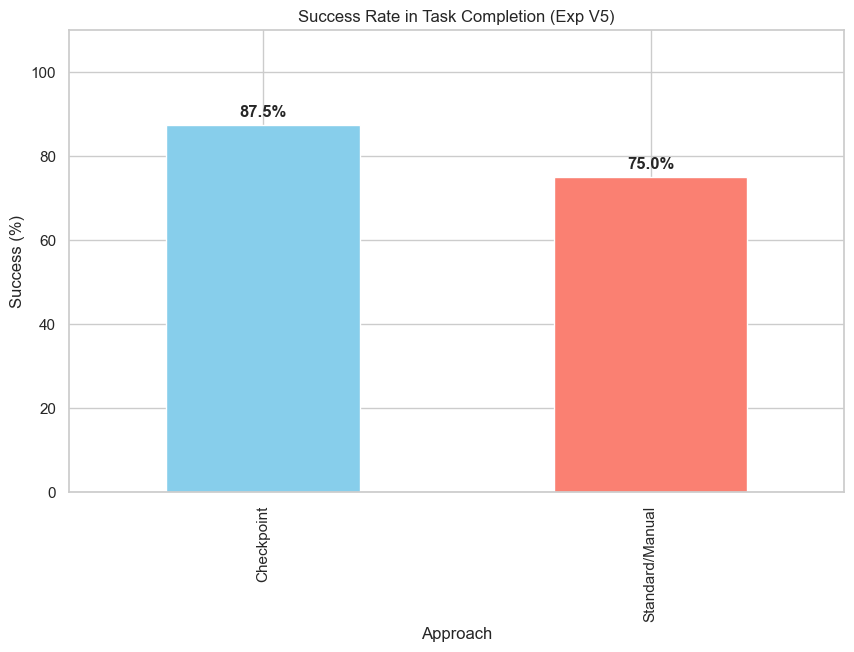

In [26]:
success_rates = v5_df.groupby('baseline')['success'].mean() * 100

plt.figure(figsize=(10, 6))
success_rates.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Success Rate in Task Completion (Exp V5)")
plt.ylabel("Success (%)")
plt.xlabel("Approach")
plt.ylim(0, 110)

for i, v in enumerate(success_rates):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.savefig(os.path.join(FIGURES_DIR, "v5_success_rate.png"))
plt.show()

Given the smaller number of trials in Experiment 5, we can also visualize the individual results to see the exact distribution of successes and failures.

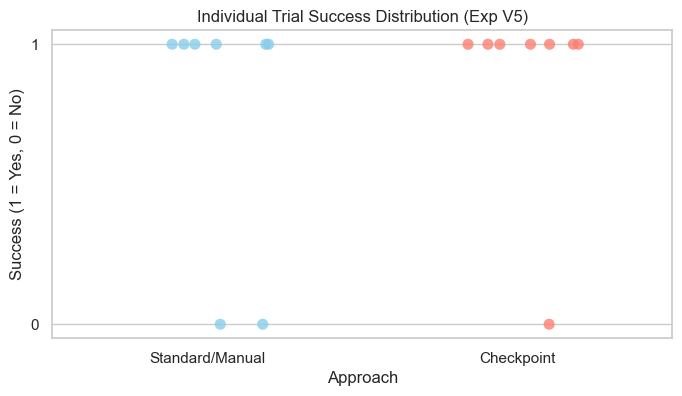

In [27]:
plt.figure(figsize=(8, 4))
sns.stripplot(x='baseline', y='success', data=v5_df, jitter=0.2, size=8, alpha=0.8, palette=["skyblue", "salmon"], hue='baseline', legend=False)
plt.title("Individual Trial Success Distribution (Exp V5)")
plt.ylabel("Success (1 = Yes, 0 = No)")
plt.xlabel("Approach")
plt.yticks([0, 1])

plt.savefig(os.path.join(FIGURES_DIR, "v5_success_strip.png"))
plt.show()

## 2. Context Pollution (Context Hygiene)

The accumulation of error logs and failed repair attempts pollutes the agent's context. Checkpoints allow it to "cleanse" its physical and cognitive past.

/var/folders/pq/ylg5_ggn3c5cb_pv0f329vm00000gn/T/ipykernel_70329/3674624086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='baseline', y='context_pollution', data=v5_df, palette="coolwarm")


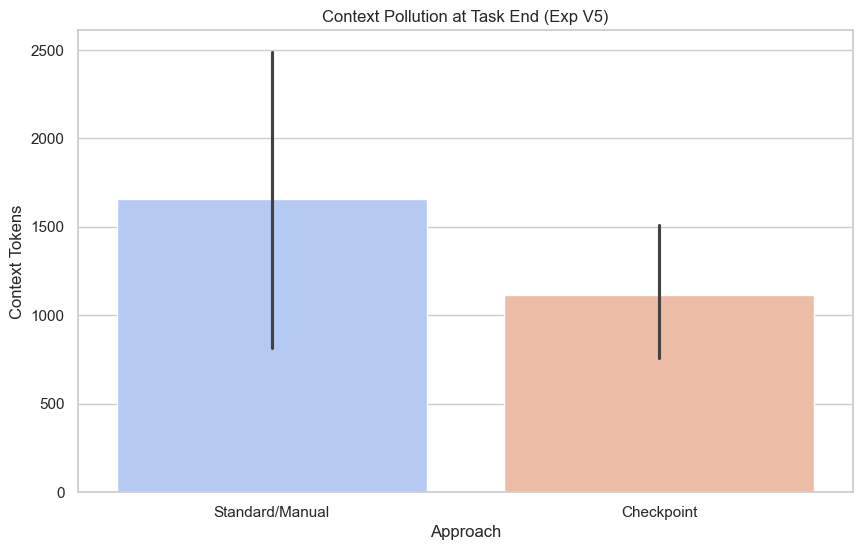

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='baseline', y='context_pollution', data=v5_df, palette="coolwarm")
plt.title("Context Pollution at Task End (Exp V5)")
plt.ylabel("Context Tokens")
plt.xlabel("Approach")

plt.savefig(os.path.join(FIGURES_DIR, "v5_context_pollution.png"))
plt.show()

## 3. Token Efficiency

Even in long tasks, checkpoints reduce rework and, consequently, the total cost.

/var/folders/pq/ylg5_ggn3c5cb_pv0f329vm00000gn/T/ipykernel_70329/1603880916.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='baseline', y='tokens', data=v5_df, palette="Set2")


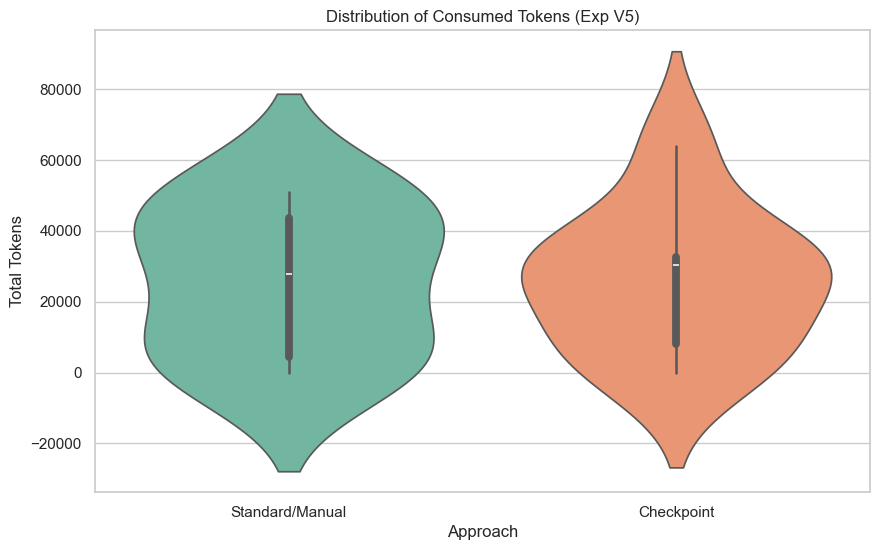

In [29]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='baseline', y='tokens', data=v5_df, palette="Set2")
plt.title("Distribution of Consumed Tokens (Exp V5)")
plt.ylabel("Total Tokens")
plt.xlabel("Approach")

plt.savefig(os.path.join(FIGURES_DIR, "v5_tokens_violin.png"))
plt.show()

## 4. Preliminary Conclusions

The findings for Experiment V5 show:
1. **Reliability:** Agents with checkpoints achieve a higher completion rate in complex migration flows.
2. **Context Hygiene:** The reduction in context pollution is drastic (~50%), suggesting that checkpoints act as pruning on the agent's decision tree.
3. **Proactive Use:** The agents demonstrate autonomy to save states before operations they label as "risky".